In [13]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [4]:
customers = pd.read_csv('customers_sample.csv')
category_spends = pd.read_csv('category_spends_sample.csv')
baskets = pd.read_csv('baskets_sample.csv')
lineitems = pd.read_csv('lineitems_sample.csv')

print("customers:", customers.shape)
print("category_spends:", category_spends.shape)
print("baskets:", baskets.shape)
print("lineitems:", lineitems.shape)

customers: (3000, 6)
category_spends: (3000, 21)
baskets: (195547, 5)
lineitems: (1461315, 6)


In [6]:
display(customers.head())
display(category_spends.head())
display(baskets.head())
display(lineitems.head())

,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend
0,4749,220,260,1.181818,£631.12,£2.87
1,4757,248,333,1.342742,£452.42,£1.82
2,144,226,303,1.340708,£261.16,£1.16
3,572,285,346,1.214035,£638.79,£2.24
4,669,285,324,1.136842,£561.42,£1.97


,customer_number,fruit_veg,dairy,confectionary,grocery_food,grocery_health_pets,bakery,newspapers_magazines,prepared_meals,soft_drinks,frozen,meat,tobacco,drinks,deli,world_foods,lottery,cashpoint,seasonal_gifting,discount_bakery,practical_items
0,11387,£64.58,£35.91,£107.78,£27.08,£29.59,£0.00,£54.83,£6.35,£22.83,£21.51,£28.62,£162.10,£28.02,£28.12,£28.54,£2.00,£15.00,£7.48,£0.00,£0.84
1,8171,£16.89,£37.24,£28.84,£33.43,£66.40,£0.00,£22.06,£12.09,£2.34,£78.74,£26.44,£0.00,£8.42,£2.65,£3.76,£0.00,£0.00,£9.99,£0.00,£0.00
2,1060,£87.30,£82.98,£49.88,£20.57,£37.04,£0.00,£9.85,£57.98,£31.12,£14.53,£54.65,£0.00,£0.00,£2.60,£0.00,£18.00,£20.00,£106.46,£0.00,£0.00
3,3728,£84.05,£186.56,£175.50,£119.84,£111.08,£0.00,£13.05,£25.54,£124.42,£15.24,£0.95,£127.70,£0.00,£0.00,£0.00,£4.00,£0.00,£0.00,£0.00,£4.50
4,14621,£35.16,£121.31,£79.23,£29.03,£37.17,£0.00,£40.06,£0.00,£4.68,£3.33,£36.24,£0.00,£2.55,£99.16,£0.00,£0.00,£0.00,£3.40,£0.00,£0.00


,customer_number,purchase_time,basket_quantity,basket_spend,basket_categories
0,11911,2007-03-01 07:06:00,7,£3.09,3
1,4047,2007-03-01 07:13:00,9,£7.99,5
2,3571,2007-03-01 07:27:00,9,£37.06,6
3,4079,2007-03-01 07:34:00,11,£11.91,5
4,6063,2007-03-01 07:36:00,3,£1.45,1


,customer_number,purchase_time,product_id,category,quantity,spend
0,14577,2007-03-10 11:58:00,722653,GROCERY_FOOD,1,£1.39
1,7210,2007-03-22 10:53:00,696136,GROCERY_HEALTH_PETS,1,£4.25
2,3145,2007-03-26 11:17:00,139543,GROCERY_HEALTH_PETS,1,£0.50
3,2649,2007-03-12 16:05:00,34890,BAKERY,1,£0.57
4,859,2007-03-10 09:53:00,613984,BAKERY,1,£1.59


In [7]:
def parse_pounds(series: pd.Series) -> pd.Series:    
    return (
        series.astype(str)
        .str.replace("£", "", regex=False)      #remove "£" symbol
        .str.replace(",", "", regex=False)      #remove commas
        .replace("nan", np.nan)                 #replace "nan" strings with actual NaN values
        .astype(float)                          #convert to float
    )


customers["total_spend"] = parse_pounds(customers["total_spend"])
customers["average_spend"] = parse_pounds(customers["average_spend"])

baskets["basket_spend"] = parse_pounds(baskets["basket_spend"])     # Baskets: basket_spend

cat_cols = [c for c in category_spends.columns if c != "customer_number"]       # Category spends: all category columns except customer_number
for c in cat_cols:
    category_spends[c] = parse_pounds(category_spends[c])
    
lineitems["spend"] = parse_pounds(lineitems["spend"])       # Lineitems: spend

In [8]:
display(customers.head())
display(category_spends.head())
display(baskets.head())
display(lineitems.head())

,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend
0,4749,220,260,1.181818,631.12,2.87
1,4757,248,333,1.342742,452.42,1.82
2,144,226,303,1.340708,261.16,1.16
3,572,285,346,1.214035,638.79,2.24
4,669,285,324,1.136842,561.42,1.97


,customer_number,fruit_veg,dairy,confectionary,grocery_food,grocery_health_pets,bakery,newspapers_magazines,prepared_meals,soft_drinks,frozen,meat,tobacco,drinks,deli,world_foods,lottery,cashpoint,seasonal_gifting,discount_bakery,practical_items
0,11387,64.58,35.91,107.78,27.08,29.59,0.0,54.83,6.35,22.83,21.51,28.62,162.1,28.02,28.12,28.54,2.0,15.0,7.48,0.0,0.84
1,8171,16.89,37.24,28.84,33.43,66.40,0.0,22.06,12.09,2.34,78.74,26.44,0.0,8.42,2.65,3.76,0.0,0.0,9.99,0.0,0.00
2,1060,87.30,82.98,49.88,20.57,37.04,0.0,9.85,57.98,31.12,14.53,54.65,0.0,0.00,2.60,0.00,18.0,20.0,106.46,0.0,0.00
3,3728,84.05,186.56,175.50,119.84,111.08,0.0,13.05,25.54,124.42,15.24,0.95,127.7,0.00,0.00,0.00,4.0,0.0,0.00,0.0,4.50
4,14621,35.16,121.31,79.23,29.03,37.17,0.0,40.06,0.00,4.68,3.33,36.24,0.0,2.55,99.16,0.00,0.0,0.0,3.40,0.0,0.00


,customer_number,purchase_time,basket_quantity,basket_spend,basket_categories
0,11911,2007-03-01 07:06:00,7,3.09,3
1,4047,2007-03-01 07:13:00,9,7.99,5
2,3571,2007-03-01 07:27:00,9,37.06,6
3,4079,2007-03-01 07:34:00,11,11.91,5
4,6063,2007-03-01 07:36:00,3,1.45,1


,customer_number,purchase_time,product_id,category,quantity,spend
0,14577,2007-03-10 11:58:00,722653,GROCERY_FOOD,1,1.39
1,7210,2007-03-22 10:53:00,696136,GROCERY_HEALTH_PETS,1,4.25
2,3145,2007-03-26 11:17:00,139543,GROCERY_HEALTH_PETS,1,0.50
3,2649,2007-03-12 16:05:00,34890,BAKERY,1,0.57
4,859,2007-03-10 09:53:00,613984,BAKERY,1,1.59


In [9]:
baskets["purchase_time"] = pd.to_datetime(baskets["purchase_time"], errors="coerce")        # Convert purchase_time to datetime, coercing errors to NaT
lineitems["purchase_time"] = pd.to_datetime(lineitems["purchase_time"], errors="coerce")    

baskets["purchase_time"].min(), baskets["purchase_time"].max()

(Timestamp('2007-03-01 07:06:00'), Timestamp('2007-08-31 21:55:00'))

In [10]:
# Bakery spend per customer from lineitems
bakery_from_lineitems = (
    lineitems.loc[lineitems["category"].str.upper().eq("BAKERY")]                                       # Filter lineitems for category "BAKERY" (case-insensitive)
    .groupby("customer_number")["spend"]
    .sum()
    .rename("bakery_recalc")
    .reset_index()
)
category_spends = category_spends.merge(bakery_from_lineitems, on="customer_number", how="left")        # Merge with category_spends to get bakery_recalc column
category_spends["bakery_recalc"] = category_spends["bakery_recalc"].fillna(0.0)                         # Fill NaN values with 0.0

if "bakery" in category_spends.columns:                                                                 # If original bakery column exists, compare with recalculated values
    category_spends["bakery"] = category_spends["bakery_recalc"]    

category_spends.drop(columns=["bakery_recalc"], inplace=True)

In [11]:
category_spends["bakery"].describe()

count    3000.000000
mean       38.210123
std        36.496115
min         0.000000
25%        14.635000
50%        29.270000
75%        50.050000
max       444.370000
Name: bakery, dtype: float64

## EDA — quick distribution snapshots

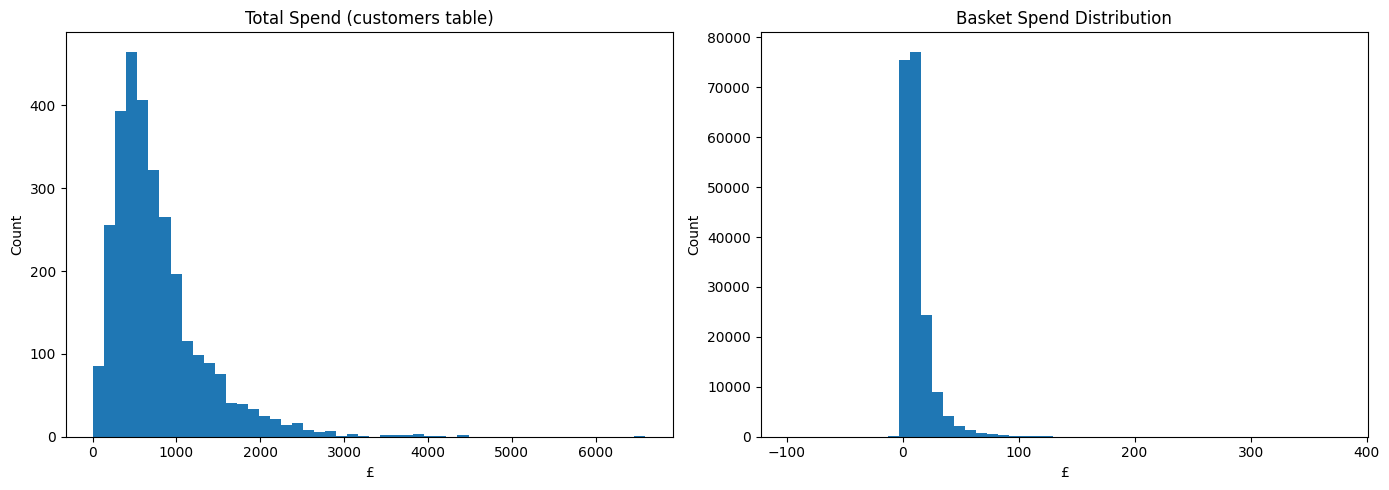

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of total_spend from customers table
axes[0].hist(customers["total_spend"], bins=50)
axes[0].set_title("Total Spend (customers table)")
axes[0].set_xlabel("£")
axes[0].set_ylabel("Count")

# Histogram of basket_spend from baskets table
axes[1].hist(baskets["basket_spend"], bins=50)
axes[1].set_title("Basket Spend Distribution")
axes[1].set_xlabel("£")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Feature engineering (customer-level)

In [27]:
ref_date = baskets["purchase_time"].max()       # # Reference date for recency = latest purchase in dataset

b = baskets.copy()
b["date"] = b["purchase_time"].dt.date
b["hour"] = b["purchase_time"].dt.hour
b["dow"] = b["purchase_time"].dt.dayofweek  # Monday=0, Sunday=6
b["is_weekend"] = (b["dow"] >= 5).astype(int)       # Weekend indicator (1 if Saturday or Sunday, 0 otherwise)

def daypart(hour):      # Define daypart based on hour of purchase
    if pd.isna(hour):
        return np.nan
    if hour < 12:
        return "morning"
    elif hour < 18:
        return "afternoon"
    else:
        return "evening"

b["daypart"] = b["hour"].apply(daypart)

basket_agg = b.groupby("customer_number").agg(      # Aggregate features from baskets table
    frequency_baskets=("purchase_time", "count"),
    monetary_basket_spend=("basket_spend", "sum"),
    avg_basket_spend=("basket_spend", "mean"),
    avg_basket_qty=("basket_quantity", "mean"),
    avg_basket_categories=("basket_categories", "mean"),
    last_purchase=("purchase_time", "max"),
    weekend_share=("is_weekend", "mean"),
)

basket_agg["recency_days"] = (ref_date - basket_agg["last_purchase"]).dt.days       # Calculate recency in days
basket_agg.drop(columns=["last_purchase"], inplace=True)

daypart_counts = (b.pivot_table(index="customer_number", columns="daypart", values="purchase_time", aggfunc="count", fill_value=0))     # Count purchases in each daypart per customer using pivot_table
daypart_shares = daypart_counts.div(daypart_counts.sum(axis=1), axis=0).add_prefix("share_")

features_baskets = basket_agg.join(daypart_shares, how="left").fillna(0)

features_baskets.head()

,frequency_baskets,monetary_basket_spend,avg_basket_spend,avg_basket_qty,avg_basket_categories,weekend_share,recency_days,share_afternoon,share_evening,share_morning
customer_number,,,,,,,,,,
14,56,675.72,12.066429,9.482143,4.464286,0.339286,1,0.857143,0.071429,0.071429
45,33,585.73,17.749394,19.848485,6.393939,0.000000,1,0.818182,0.030303,0.151515
52,59,222.18,3.765763,4.983051,2.949153,0.016949,2,0.644068,0.000000,0.355932
61,37,547.87,14.807297,13.486486,6.027027,0.135135,3,0.891892,0.027027,0.081081
63,48,293.34,6.111250,5.854167,3.666667,0.187500,7,0.770833,0.041667,0.187500


In [28]:
cat_cols = [c for c in category_spends.columns if c != "customer_number"]

cat = category_spends.copy()
cat["total_category_spend"] = cat[cat_cols].sum(axis=1)

cat["total_category_spend"] = cat["total_category_spend"].replace(0, np.nan)        # Avoid divide-by-zero by replacing 0 total spend with NaN

for c in cat_cols:
    cat[f"share_{c}"] = cat[c] / cat["total_category_spend"]

share_cols = [f"share_{c}" for c in cat_cols]
features_category = cat[["customer_number"] + share_cols].fillna(0)

features_category.head()

,customer_number,share_fruit_veg,share_dairy,share_confectionary,share_grocery_food,share_grocery_health_pets,share_bakery,share_newspapers_magazines,share_prepared_meals,share_soft_drinks,share_frozen,share_meat,share_tobacco,share_drinks,share_deli,share_world_foods,share_lottery,share_cashpoint,share_seasonal_gifting,share_discount_bakery,share_practical_items
0,11387,0.092553,0.051465,0.154466,0.038810,0.042407,0.038093,0.078580,0.009101,0.032719,0.030827,0.041017,0.232315,0.040157,0.040300,0.040902,0.002866,0.021497,0.010720,0.0,0.001204
1,8171,0.045734,0.100837,0.078092,0.090520,0.179795,0.054209,0.059733,0.032737,0.006336,0.213208,0.071593,0.000000,0.022799,0.007176,0.010181,0.000000,0.000000,0.027050,0.0,0.000000
2,1060,0.130556,0.124095,0.074595,0.030762,0.055393,0.113238,0.014731,0.086708,0.046539,0.021729,0.081728,0.000000,0.000000,0.003888,0.000000,0.026919,0.029910,0.159209,0.0,0.000000
3,3728,0.076125,0.168970,0.158953,0.108541,0.100607,0.101141,0.011820,0.023132,0.112689,0.013803,0.000860,0.115660,0.000000,0.000000,0.000000,0.003623,0.000000,0.000000,0.0,0.004076
4,14621,0.067042,0.231309,0.151073,0.055353,0.070874,0.063171,0.076385,0.000000,0.008924,0.006350,0.069101,0.000000,0.004862,0.189074,0.000000,0.000000,0.000000,0.006483,0.0,0.000000


In [29]:
base = customers.copy()
base = base.merge(features_baskets.reset_index(), on="customer_number", how="left")     # Merge basket features
base = base.merge(features_category, on="customer_number", how="left")      # Merge category features
base = base.fillna(0)       # Fill any missing (e.g., if a customer has no baskets—unlikely but safe)

base.shape, base.head()

((3000, 36),
    customer_number  baskets  total_quantity  average_quantity  total_spend  average_spend  frequency_baskets  monetary_basket_spend  \
 0             4749      220             260          1.181818       631.12           2.87                 92                 631.12   
 1             4757      248             333          1.342742       452.42           1.82                 27                 452.42   
 2              144      226             303          1.340708       261.16           1.16                 22                 261.16   
 3              572      285             346          1.214035       638.79           2.24                 40                 638.79   
 4              669      285             324          1.136842       561.42           1.97                 36                 561.42   
 
    avg_basket_spend  avg_basket_qty  avg_basket_categories  weekend_share  recency_days  share_afternoon  share_evening  share_morning  \
 0          6.860000        2.

## Feature selection sanity check

In [35]:
# Drop potentially redundant columns
drop_cols = [
    "baskets",               # from customers table
    "total_spend",           # customers table version 
    "average_spend",         # may correlate strongly with avg_basket_spend
    "total_quantity",        # may correlate with frequency & avg qty
    "average_quantity"       # may correlate with avg_basket_qty
]

keep = base.drop(columns=[c for c in drop_cols if c in base.columns])       # Drop columns if they exist in the base dataframe
feature_cols = [c for c in keep.columns if c != "customer_number"]
X = keep[feature_cols].copy()
print(f'Features shape(X): {X.shape}')

Features shape(X): (3000, 30)


## Preprocessing: log transform + scaling

In [36]:
from sklearn.preprocessing import StandardScaler

X_proc = X.copy()
log_candidates = []     # Decide which columns to log:
for col in X_proc.columns:
    # Simple heuristic: log the "money/qty/recency" style continuous positives, not shares
    if col.startswith("share_"):
        continue
    if col in ["weekend_share", "share_morning", "share_afternoon", "share_evening"]:
        continue
    log_candidates.append(col)

# Ensure non-negative before log1p (recency is non-negative; spends should be too)
for col in log_candidates:
    X_proc[col] = np.log1p(np.clip(X_proc[col], a_min=0, a_max=None))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_proc)
print(f'X_scaled shape: {X_scaled.shape}')

X_scaled shape: (3000, 30)


In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = [5, 6, 7]
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)        # Inertia (within-cluster sum of squares)
    silhouettes.append(silhouette_score(X_scaled, labels))      # Silhouette score (higher is better)

results = pd.DataFrame({"k": ks, "inertia": inertias, "silhouette": silhouettes})
results

,k,inertia,silhouette
0,5,72206.599023,0.072630
1,6,70525.323542,0.069531
2,7,68538.526165,0.069821


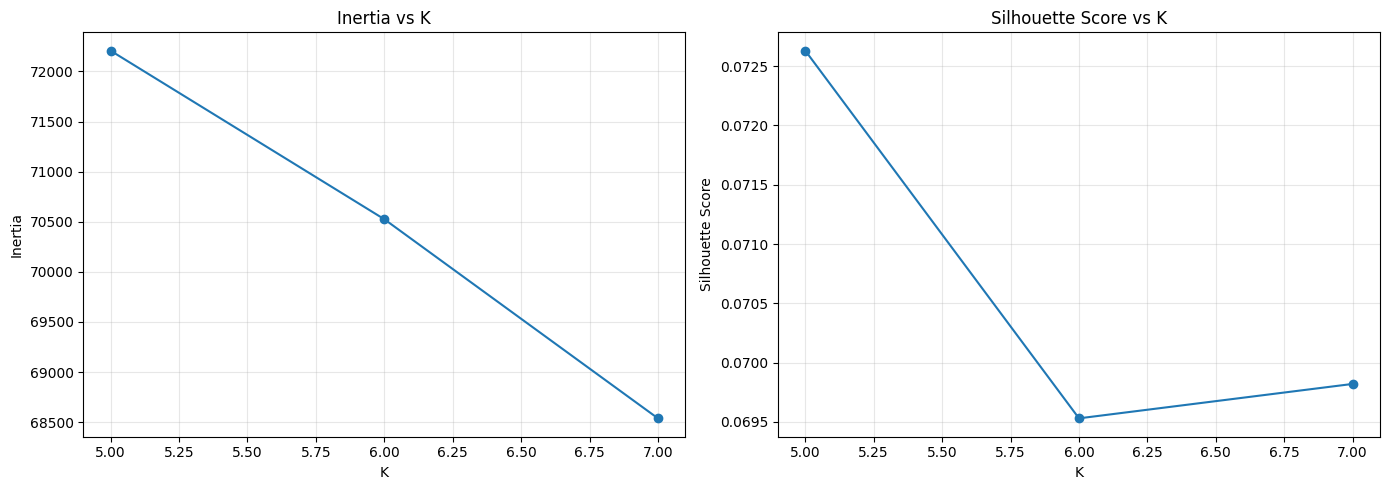

In [50]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Inertia (Elbow)
axes[0].plot(results["k"], results["inertia"], marker="o")
axes[0].set_title("Inertia vs K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(results["k"], results["silhouette"], marker="o")
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
best_idx = results["silhouette"].to_numpy().argmax()
best_k = results["k"].to_numpy(dtype=np.int64)[best_idx].item()
print(f'best k among is {best_k}')

best k among is 5


In [53]:
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=20)       
segment_idx = final_km.fit_predict(X_scaled)        

seg = keep[["customer_number"]].copy()
seg["segment_id"] = segment_idx + 1     # +1 to make segment IDs 1-indexed instead of 0-indexed
seg["segment_name"] = seg["segment_id"].apply(lambda x: f"Customer clutter {x}")

seg.head()

,customer_number,segment_id,segment_name
0,4749,3,Customer clutter 3
1,4757,2,Customer clutter 2
2,144,2,Customer clutter 2
3,572,3,Customer clutter 3
4,669,5,Customer clutter 5


In [55]:
segment_sizes = (               # Calculate segment sizes by counting customers in each segment_name
    seg["segment_name"]
    .value_counts()
    .rename_axis("segment_name")
    .reset_index(name="n_customers")
)

segment_sizes["pct_customers"] = segment_sizes["n_customers"] / segment_sizes["n_customers"].sum()      # Add percentage of customers in each segment
segment_sizes

,segment_name,n_customers,pct_customers
0,Customer clutter 2,840,0.280000
1,Customer clutter 4,764,0.254667
2,Customer clutter 3,590,0.196667
3,Customer clutter 1,505,0.168333
4,Customer clutter 5,301,0.100333


In [ ]:
profile_df = keep.merge(seg, on="customer_number", how="left")

key_features = [        # smaller set of key features for the main table
    "frequency_baskets",
    "monetary_basket_spend",
    "avg_basket_spend",
    "avg_basket_qty",
    "avg_basket_categories",
    "recency_days",
    "weekend_share",
]

for c in ["share_morning", "share_afternoon", "share_evening"]:
    if c in profile_df.columns:
        key_features.append(c)

summary_means = profile_df.groupby("segment_name")[key_features].mean().round(3)
summary_medians = profile_df.groupby("segment_name")[key_features].median().round(3)

summary_means

,frequency_baskets,monetary_basket_spend,avg_basket_spend,avg_basket_qty,avg_basket_categories,recency_days,weekend_share,share_morning,share_afternoon,share_evening
segment_name,,,,,,,,,,
Customer clutter 1,77.291,660.023,9.592,8.903,4.349,4.303,0.201,0.736,0.245,0.019
Customer clutter 2,60.325,526.373,9.405,8.172,4.100,9.168,0.241,0.202,0.671,0.127
Customer clutter 3,94.303,1001.688,12.184,6.355,3.598,4.873,0.221,0.350,0.512,0.138
Customer clutter 4,36.876,904.199,27.052,21.617,6.710,11.674,0.243,0.285,0.605,0.110
Customer clutter 5,73.189,833.787,12.635,7.294,3.938,8.947,0.251,0.212,0.570,0.218


In [ ]:
cat_share_cols = []
for col in profile_df.columns:
    if col.startswith("share_") and col not in ["share_morning","share_afternoon","share_evening"]:     # Identify category share columns (those starting with "share_" but not the daypart shares)
        cat_share_cols.append(col)

seg_cat_means = profile_df.groupby("segment_name")[cat_share_cols].mean()

top5_by_segment = {}
for seg_name in seg_cat_means.index:        # For each segment, find the top 5 category shares
    row = seg_cat_means.loc[seg_name]
    top5 = row.sort_values(ascending=False).head(5)
    top5_by_segment[seg_name] = top5

for seg_name in top5_by_segment:
    print("\nSegment:", seg_name)
    print("------------------------")
    for category, value in top5_by_segment[seg_name].items():
        clean_name = category.replace("share_", "")
        print(clean_name, ":", round(value, 3))


Segment: Customer clutter 1
------------------------
dairy : 0.122
fruit_veg : 0.114
grocery_food : 0.103
confectionary : 0.09
grocery_health_pets : 0.079

Segment: Customer clutter 2
------------------------
dairy : 0.123
fruit_veg : 0.114
confectionary : 0.097
grocery_food : 0.085
grocery_health_pets : 0.08

Segment: Customer clutter 3
------------------------
tobacco : 0.316
cashpoint : 0.171
dairy : 0.057
confectionary : 0.047
lottery : 0.045

Segment: Customer clutter 4
------------------------
fruit_veg : 0.116
grocery_health_pets : 0.115
grocery_food : 0.109
dairy : 0.106
confectionary : 0.094

Segment: Customer clutter 5
------------------------
drinks : 0.376
tobacco : 0.084
meat : 0.07
fruit_veg : 0.065
dairy : 0.062


## Pen profiles (customer archetypes)

A good pen profile usually mentions:
- **Value** (high/low spend; basket spend)
- **Frequency** (regular vs occasional)
- **Mission** (quick top-up vs broad shop: avg_basket_categories, avg_basket_qty)
- **Timing** (weekend/morning/evening)
- **Preferences** (top categories by share)

In [73]:
def fmt_pct(x):
    return f"{100*x:.1f}%"

pen_profile_rows = []
for seg_name in sorted(profile_df["segment_name"].unique()):
    sub = profile_df[profile_df["segment_name"] == seg_name]

    # calculate key stats
    avg_spend = sub["avg_basket_spend"].mean()
    freq = sub["frequency_baskets"].mean()
    rec = sub["recency_days"].mean()
    weekend = sub["weekend_share"].mean()
    cats = sub["avg_basket_categories"].mean()

    
    top_cats = seg_cat_means.loc[seg_name].sort_values(ascending=False).head(3)     # Get top 3 category shares for this segment
    top_cats_str = ", ".join([f"{c.replace('share_','')} ({fmt_pct(v)})" for c,v in top_cats.items()])

    # store results
    pen_profile_rows.append({
        "segment_name": seg_name,
        "frequency_baskets": round(freq, 1),
        "avg_basket_spend": round(avg_spend, 2),
        "recency_days": round(rec, 1),
        "weekend_share": fmt_pct(weekend),
        "basket_category_breadth": round(cats, 2),
        "top_categories": top_cats_str,
        "pen_profile_prompt": (
            f"{seg_name}: visits ~{freq:.1f} times, spends ~£{avg_spend:.2f} per basket, "
            f"last visited ~{rec:.1f} days ago, shops on weekends ~{fmt_pct(weekend)}, "
            f"buys across ~{cats:.2f} categories. Top categories: {top_cats_str}."
        )
    })


pen_profiles = pd.DataFrame(pen_profile_rows)
pd.set_option('display.max_colwidth', None)
pen_profiles[["segment_name", "pen_profile_prompt"]]    # show only segment name and profile text

,segment_name,pen_profile_prompt
0,Customer clutter 1,"Customer clutter 1: visits ~77.3 times, spends ~£9.59 per basket, last visited ~4.3 days ago, shops on weekends ~20.1%, buys across ~4.35 categories. Top categories: dairy (12.2%), fruit_veg (11.4%), grocery_food (10.3%)."
1,Customer clutter 2,"Customer clutter 2: visits ~60.3 times, spends ~£9.40 per basket, last visited ~9.2 days ago, shops on weekends ~24.1%, buys across ~4.10 categories. Top categories: dairy (12.3%), fruit_veg (11.4%), confectionary (9.7%)."
2,Customer clutter 3,"Customer clutter 3: visits ~94.3 times, spends ~£12.18 per basket, last visited ~4.9 days ago, shops on weekends ~22.1%, buys across ~3.60 categories. Top categories: tobacco (31.6%), cashpoint (17.1%), dairy (5.7%)."
3,Customer clutter 4,"Customer clutter 4: visits ~36.9 times, spends ~£27.05 per basket, last visited ~11.7 days ago, shops on weekends ~24.3%, buys across ~6.71 categories. Top categories: fruit_veg (11.6%), grocery_health_pets (11.5%), grocery_food (10.9%)."
4,Customer clutter 5,"Customer clutter 5: visits ~73.2 times, spends ~£12.64 per basket, last visited ~8.9 days ago, shops on weekends ~25.1%, buys across ~3.94 categories. Top categories: drinks (37.6%), tobacco (8.4%), meat (7.0%)."


In [75]:
seg_kpis = profile_df.groupby("segment_name").agg(      # Aggregate key KPIs by segment for attractiveness scoring
    n_customers=("customer_number", "count"),
    mean_frequency=("frequency_baskets", "mean"),
    mean_monetary=("monetary_basket_spend", "mean"),
    mean_recency=("recency_days", "mean"),
    mean_avg_basket_spend=("avg_basket_spend", "mean")
).reset_index()

def minmax(s):
    if s.max() == s.min():      # handle constant series to avoid divide-by-zero
        return np.zeros_like(s, dtype=float)
    return (s - s.min()) / (s.max() - s.min())

tmp = seg_kpis.copy()
tmp["freq_norm"] = minmax(tmp["mean_frequency"])    # Normalize frequency higher = better
tmp["mon_norm"] = minmax(tmp["mean_monetary"])      # Normalize monetary higher = better
tmp["rec_norm"] = 1 - minmax(tmp["mean_recency"])   # lower recency = better

w_freq, w_mon, w_rec = 0.35, 0.45, 0.20  # weights can be justified in the report

tmp["attractiveness_score"] = (
    w_freq * tmp["freq_norm"] +
    w_mon * tmp["mon_norm"] +
    w_rec * tmp["rec_norm"]
)

seg_ranking = tmp.sort_values("attractiveness_score", ascending=False)      # Sort segments by attractiveness
seg_ranking

,segment_name,n_customers,mean_frequency,mean_monetary,mean_recency,mean_avg_basket_spend,freq_norm,mon_norm,rec_norm,attractiveness_score
2,Customer clutter 3,590,94.303390,1001.687627,4.872881,12.184346,1.000000,1.000000,0.922683,0.984537
4,Customer clutter 5,301,73.189369,833.787309,8.946844,12.635178,0.632338,0.646759,0.369990,0.586358
0,Customer clutter 1,505,77.291089,660.022515,4.302970,9.591879,0.703762,0.281181,1.000000,0.572848
3,Customer clutter 4,764,36.875654,904.199084,11.674084,27.051560,0.000000,0.794897,0.000000,0.357703
1,Customer clutter 2,840,60.325000,526.373405,9.167857,9.404968,0.408328,0.000000,0.340007,0.210916


In [76]:
output_path = "customer_segment_assignments.csv"
seg.sort_values("customer_number").to_csv(output_path, index=False)
output_path

'customer_segment_assignments.csv'